1. Importation des dépendances (modules)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2. Génération des données

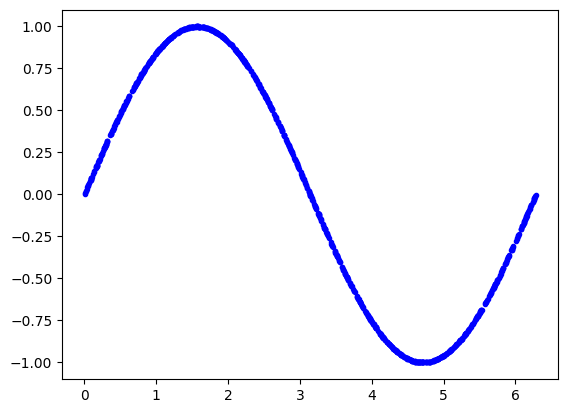

In [2]:
SAMPLES = 1000 # nombres d'échantillons considérés
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

x_values = np.random.uniform(low=0, high=2 * np.pi, size=SAMPLES)
np.random.shuffle(x_values)

y_values = np.sin(x_values)

plt.plot(x_values, y_values, "b.")
plt.show()

3. Ajout des bruits aux données

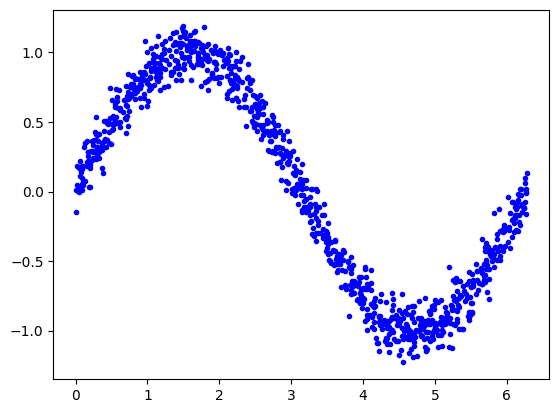

In [3]:
y_values += 0.1 * np.random.randn(*y_values.shape)

plt.plot(x_values, y_values, "b.")
plt.show()

4. Partition des données en trois groupe (Entrainement, Validation et Test)

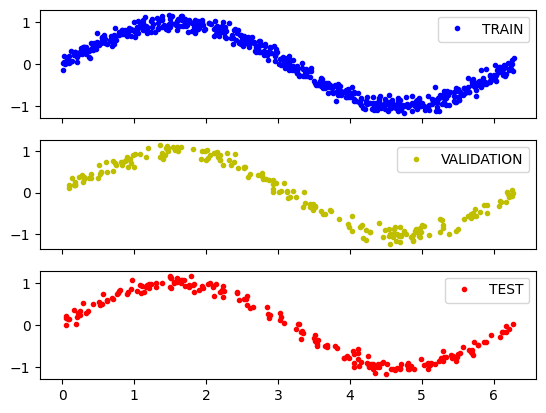

In [4]:
TRAIN_SPLIT = int(0.6 * SAMPLES)                # 60% des données
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT)   # 20% des données

x_train, x_validate, x_test = np.split(x_values, (TRAIN_SPLIT, TEST_SPLIT))
y_train, y_validate, y_test = np.split(y_values, (TRAIN_SPLIT, TEST_SPLIT))

# vérification
assert (x_train.size + x_validate.size + x_test.size) == SAMPLES

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.plot(x_train, y_train, "b.", label="TRAIN")
ax1.legend()
ax2.plot(x_validate, y_validate, "y.", label="VALIDATION")
ax2.legend()
ax3.plot(x_test, y_test, "r.", label="TEST")
ax3.legend()
plt.show()

5. Modèle "deep learning" simple

In [5]:
layer = tf.keras.layers
model_1 = tf.keras.Sequential()

model_1.add(layer.Dense(16, activation="relu", input_shape=(1,))) # première couche
# relu = rectified linear unit, the activation function
model_1.add(layer.Dense(1))
model_1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

model_1.summary()

C:\Users\itel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

6. Première phase : Entrainement du modèle

In [6]:
history_1 = model_1.fit(x_train, y_train, epochs=1000, batch_size=16,
                        validation_data=(x_validate, y_validate))

Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.4077 - mae: 0.5583 - val_loss: 0.4052 - val_mae: 0.5536
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.3646 - mae: 0.5242 - val_loss: 0.3683 - val_mae: 0.5244
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.3325 - mae: 0.5006 - val_loss: 0.3361 - val_mae: 0.4988
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.3042 - mae: 0.4792 - val_loss: 0.3077 - val_mae: 0.4762
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2794 - mae: 0.4599 - val_loss: 0.2829 - val_mae: 0.4559
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.2580 - mae: 0.4430 - val_loss: 0.2616 - val_mae: 0.4389
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.2400 - mae: 0.4282 - val_loss: 0.2438 - val_mae: 0.4246
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.2251 - mae: 0.4155 - val_loss: 0.2292 - val_mae: 0.4126
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/

In [ ]:
loss = history_1.history["loss"]
val_loss = history_1.history["val_loss"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs[100:], loss[100:], "g.", label="Training loss")
plt.plot(epochs[100:], val_loss[100:], "b", label="Validation loss")
plt.title("Pertes d'entrainement et de validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

7. Prediction

In [ ]:
predictions = model_1.predict(x_train)

plt.clf()
plt.title("Prédiction contre vraies valeurs")
plt.plot(x_test, y_test, "b.", label="Vraies valeurs")
plt.plot(x_train, predictions, "r.", label="Prédictions")
plt.legend()
plt.show()

8. Modèle amélioré

In [ ]:
model_2 = tf.keras.Sequential()
model_2.add(layer.Dense(16, activation="relu", input_shape=(1,))) # Première couche
model_2.add(layer.Dense(16, activation="relu"))                   # Deuxième couche
model_2.add(layer.Dense(1))                                       # Dernière couche

model_2.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model_2.summary()

9. Entrainement de ce deuxième modèle

In [ ]:
history_2 = model_2.fit(x_train, y_train, epochs=600, batch_size=16,
                        validation_data=(x_validate, y_validate))

In [ ]:
loss = history_2.history["loss"]
val_loss = history_2.history["val_loss"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs[100:], loss[100:], "g.", label="Training loss")
plt.plot(epochs[100:], val_loss[100:], "b", label="Validation loss")
plt.title("Pertes d'entrainement et de validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

10. Test

In [ ]:
loss = model_2.evaluate(x_test, y_test)
predictions = model_2.predict(x_test)

plt.clf()
plt.title("Comparaison des prédictions avec des vraies valeurs")
plt.plot(x_test, y_test, "b.", label="Vraies valeurs")
plt.plot(x_test, predictions, "r.", label="valeurs prédites")
plt.legend()
plt.show()